# ESMM: Entire Space Multi-Task Model on Tenrec

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_dataset_study/blob/main/notebooks/03_tenrec_cvr/02_esmm.ipynb)
[![Paper](https://img.shields.io/badge/Paper-SIGIR%202018-blue)](https://arxiv.org/abs/1804.07931)

---

## Learning Objectives

By the end of this notebook, you will:
1. Understand the ESMM architecture and its mathematical foundation
2. Implement ESMM from scratch in PyTorch with shared embeddings
3. Implement a naive single-task like prediction baseline for comparison
4. Train both models on Tenrec data using GPU acceleration
5. Evaluate CTR AUC, Like AUC, and CTCVR AUC
6. Perform ablation studies on shared embeddings and loss weights

## Prerequisites

- Completed Notebook 01 (data exploration and preprocessing)
- Understanding of binary cross-entropy loss and AUC metrics
- Familiarity with PyTorch nn.Module and training loops

---

In [1]:
import os
import json
import time
import warnings
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, log_loss, roc_curve

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-whitegrid')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

PyTorch version: 2.4.1+cpu
Device: cpu


## 1. ESMM Theory

### The Core Insight (Ma et al., Alibaba, SIGIR 2018)

ESMM addresses the **Sample Selection Bias** problem in conversion (like) prediction through an elegant mathematical decomposition:

$$P(\text{like} | \text{impression}) = P(\text{click} | \text{impression}) \times P(\text{like} | \text{click}, \text{impression})$$

$$\boxed{\text{CTCVR} = \text{CTR} \times \text{CVR}}$$

### Architecture

ESMM has two towers:
1. **CTR Tower**: Predicts $P(\text{click} | \text{impression})$ -- trained on ALL impressions
2. **CVR Tower**: Predicts $P(\text{like} | \text{click}, \text{impression})$ -- output multiplied with CTR

Both towers share the same feature embeddings.

### Loss Function

$$\mathcal{L} = \mathcal{L}_{CTR} + \mathcal{L}_{CTCVR}$$

$$\mathcal{L}_{CTR} = -\frac{1}{N}\sum_{i=1}^{N}[y_i^{click}\log(p_i^{ctr}) + (1-y_i^{click})\log(1-p_i^{ctr})]$$

$$\mathcal{L}_{CTCVR} = -\frac{1}{N}\sum_{i=1}^{N}[y_i^{like}\log(p_i^{ctcvr}) + (1-y_i^{like})\log(1-p_i^{ctcvr})]$$

where $p_i^{ctcvr} = p_i^{ctr} \times p_i^{cvr}$

> **Concept:** The CVR tower is NEVER directly supervised. Its output only contributes to the loss through the multiplication $\text{CTCVR} = \text{CTR} \times \text{CVR}$. This is the key trick that enables training CVR on the entire impression space.

> **Common Pitfall:** Do NOT add a direct CVR loss (BCE between CVR prediction and like label on clicked samples). This would re-introduce the sample selection bias that ESMM is designed to eliminate.

## 2. Load Preprocessed Data

In [2]:
# Load preprocessed data from Notebook 01
PROCESSED_DIR = Path('../../data/Tenrec/processed')

if not (PROCESSED_DIR / 'train.csv').exists():
    raise FileNotFoundError(
        f"Processed data not found in {PROCESSED_DIR.resolve()}. "
        "Please run Notebook 01 first."
    )

train_df = pd.read_csv(PROCESSED_DIR / 'train.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test.csv')

with open(PROCESSED_DIR / 'metadata.json', 'r') as f:
    metadata = json.load(f)

feature_fields = OrderedDict(metadata['feature_fields'])
MODEL_FEATURES = metadata['model_features']
LABEL_COLS = metadata['label_cols']  # ['click', 'like']

print(f"Train: {len(train_df):,} samples")
print(f"Test:  {len(test_df):,} samples")
print(f"Features: {MODEL_FEATURES}")
print(f"Click rate (train): {train_df['click'].mean():.4f}")
print(f"Like rate all (train): {train_df['like'].mean():.6f}")
print(f"Like rate clicked (train): {train_df.loc[train_df['click']==1, 'like'].mean():.4f}")

Train: 4,000,000 samples
Test:  1,000,000 samples
Features: ['user_id', 'item_id', 'video_category', 'gender', 'age']
Click rate (train): 0.2685
Like rate all (train): 0.014757
Like rate clicked (train): 0.0266


## 3. PyTorch Dataset & DataLoader

In [3]:
class TenrecDataset(Dataset):
    """Tenrec dataset for multi-task like prediction."""
    
    def __init__(self, df, feature_names, click_col='click', like_col='like'):
        self.features = torch.LongTensor(df[feature_names].values)
        self.click = torch.FloatTensor(df[click_col].values)
        self.like = torch.FloatTensor(df[like_col].values)
    
    def __len__(self):
        return len(self.click)
    
    def __getitem__(self, idx):
        return self.features[idx], self.click[idx], self.like[idx]


# Create datasets
BATCH_SIZE = 4096

train_dataset = TenrecDataset(train_df, MODEL_FEATURES)
test_dataset = TenrecDataset(test_df, MODEL_FEATURES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2, shuffle=False,
                         num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

# Quick check
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Features: {batch[0].shape}")
print(f"  Click: {batch[1].shape}")
print(f"  Like: {batch[2].shape}")

Train batches: 977
Test batches: 123



Batch shapes:
  Features: torch.Size([4096, 5])
  Click: torch.Size([4096])
  Like: torch.Size([4096])


## 4. Model Implementation

### 4.1 Shared Embedding Layer

In [4]:
class SharedEmbedding(nn.Module):
    """Shared embedding layer for all feature fields.
    
    Each feature field gets its own embedding table. The embeddings are shared
    across CTR and CVR towers (critical for ESMM).
    """
    
    def __init__(self, feature_fields, embed_dim=16):
        super().__init__()
        self.feature_names = list(feature_fields.keys())
        self.embed_dim = embed_dim
        
        self.embeddings = nn.ModuleDict()
        for name, info in feature_fields.items():
            self.embeddings[name] = nn.Embedding(
                num_embeddings=info['cardinality'],
                embedding_dim=embed_dim,
                padding_idx=0
            )
        
        self.output_dim = len(feature_fields) * embed_dim
        self._init_weights()
    
    def _init_weights(self):
        for emb in self.embeddings.values():
            nn.init.xavier_uniform_(emb.weight)
            if emb.padding_idx is not None:
                emb.weight.data[emb.padding_idx].fill_(0)
    
    def forward(self, x):
        """x: (batch_size, n_features) -- integer feature indices."""
        embeds = []
        for i, name in enumerate(self.feature_names):
            embeds.append(self.embeddings[name](x[:, i]))
        return torch.cat(embeds, dim=1)


# Test
shared_emb = SharedEmbedding(feature_fields, embed_dim=16)
print(f"SharedEmbedding output dim: {shared_emb.output_dim}")
print(f"Total parameters: {sum(p.numel() for p in shared_emb.parameters()):,}")

test_x = batch[0][:4]
test_out = shared_emb(test_x)
print(f"Input shape: {test_x.shape} -> Output shape: {test_out.shape}")

SharedEmbedding output dim: 80
Total parameters: 10,704,784
Input shape: torch.Size([4, 5]) -> Output shape: torch.Size([4, 80])


### 4.2 Tower Networks (CTR and CVR)

In [5]:
class Tower(nn.Module):
    """MLP tower for CTR or CVR prediction.
    
    Architecture: Input -> [Linear -> BatchNorm -> ReLU -> Dropout] x N -> Linear -> Sigmoid
    """
    
    def __init__(self, input_dim, hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.mlp = nn.Sequential(*layers)
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    
    def forward(self, x):
        """Returns logits (pre-sigmoid), shape (batch_size, 1)."""
        return self.mlp(x)


tower = Tower(shared_emb.output_dim, hidden_dims=[256, 128, 64], dropout=0.3)
print(f"Tower parameters: {sum(p.numel() for p in tower.parameters()):,}")
test_logit = tower(test_out)
print(f"Tower output shape: {test_logit.shape}")

Tower parameters: 62,849
Tower output shape: torch.Size([4, 1])


### 4.3 ESMM Model

In [6]:
class ESMM(nn.Module):
    """Entire Space Multi-Task Model (ESMM).
    
    Key insight: CTCVR = CTR * CVR
    - CTR tower predicts P(click | impression)
    - CVR tower predicts P(like | click, impression)
    - CTCVR = CTR * CVR is supervised against the like label
    - Both towers share embeddings
    
    Loss = BCE(CTR_pred, click_label) + BCE(CTCVR_pred, like_label)
    """
    
    def __init__(self, feature_fields, embed_dim=16,
                 hidden_dims=(256, 128, 64), dropout=0.3,
                 ctcvr_loss_weight=1.0):
        super().__init__()
        
        # Shared embeddings
        self.embedding = SharedEmbedding(feature_fields, embed_dim)
        
        # CTR tower
        self.ctr_tower = Tower(self.embedding.output_dim, hidden_dims, dropout)
        
        # CVR tower
        self.cvr_tower = Tower(self.embedding.output_dim, hidden_dims, dropout)
        
        self.ctcvr_loss_weight = ctcvr_loss_weight
    
    def forward(self, x):
        """Forward pass.
        
        Returns:
            ctr_pred: P(click | impression)
            cvr_pred: P(like | click, impression)
            ctcvr_pred: P(like | impression) = CTR * CVR
        """
        embed = self.embedding(x)
        
        ctr_logit = self.ctr_tower(embed).squeeze(1)
        ctr_pred = torch.sigmoid(ctr_logit)
        
        cvr_logit = self.cvr_tower(embed).squeeze(1)
        cvr_pred = torch.sigmoid(cvr_logit)
        
        ctcvr_pred = ctr_pred * cvr_pred
        
        return ctr_pred, cvr_pred, ctcvr_pred
    
    def compute_loss(self, ctr_pred, ctcvr_pred, click_label, like_label):
        """Compute ESMM loss: L = L_CTR + weight * L_CTCVR."""
        ctr_loss = F.binary_cross_entropy(ctr_pred, click_label, reduction='mean')
        
        ctcvr_pred_clipped = torch.clamp(ctcvr_pred, 1e-7, 1 - 1e-7)
        ctcvr_loss = F.binary_cross_entropy(ctcvr_pred_clipped, like_label, reduction='mean')
        
        total_loss = ctr_loss + self.ctcvr_loss_weight * ctcvr_loss
        
        return total_loss, ctr_loss, ctcvr_loss


model_esmm = ESMM(
    feature_fields=feature_fields,
    embed_dim=16,
    hidden_dims=[256, 128, 64],
    dropout=0.3,
    ctcvr_loss_weight=1.0
).to(device)

total_params = sum(p.numel() for p in model_esmm.parameters())
trainable_params = sum(p.numel() for p in model_esmm.parameters() if p.requires_grad)
print(f"ESMM Model:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"\nArchitecture:")
print(model_esmm)

ESMM Model:
  Total parameters: 10,830,482
  Trainable parameters: 10,830,482

Architecture:
ESMM(
  (embedding): SharedEmbedding(
    (embeddings): ModuleDict(
      (user_id): Embedding(36440, 16, padding_idx=0)
      (item_id): Embedding(632592, 16, padding_idx=0)
      (video_category): Embedding(4, 16, padding_idx=0)
      (gender): Embedding(4, 16, padding_idx=0)
      (age): Embedding(9, 16, padding_idx=0)
    )
  )
  (ctr_tower): Tower(
    (mlp): Sequential(
      (0): Linear(in_features=80, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.3, inplace=False)
      (8): Linear(in_features=128, out_features=64, bias=True)
      (9): BatchNorm1d(64, eps=1e-05

### 4.4 Naive CVR Baseline (Single-Task)

In [7]:
class NaiveCVR(nn.Module):
    """Naive single-task like prediction model.
    
    This model is trained ONLY on clicked samples to predict like.
    It demonstrates the sample selection bias problem.
    """
    
    def __init__(self, feature_fields, embed_dim=16,
                 hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        self.embedding = SharedEmbedding(feature_fields, embed_dim)
        self.tower = Tower(self.embedding.output_dim, hidden_dims, dropout)
    
    def forward(self, x):
        embed = self.embedding(x)
        logit = self.tower(embed).squeeze(1)
        return torch.sigmoid(logit)


model_naive = NaiveCVR(
    feature_fields=feature_fields,
    embed_dim=16,
    hidden_dims=[256, 128, 64],
    dropout=0.3
).to(device)

print(f"Naive CVR Model:")
print(f"  Total parameters: {sum(p.numel() for p in model_naive.parameters()):,}")

Naive CVR Model:
  Total parameters: 10,767,633


## 5. Training

> **Pro Tip:** ESMM trains on ALL impressions (not just clicks), which means each epoch processes the full dataset. The CTR task serves as regularization for the shared embeddings, while the CTCVR task teaches the CVR tower through the multiplication.

In [8]:
def evaluate_model(model, data_loader, model_type='esmm', device=device):
    """Evaluate model on given data loader.
    
    Returns dict with CTR AUC, Like AUC (all & clicked), CTCVR AUC.
    """
    model.eval()
    
    all_ctr_preds = []
    all_cvr_preds = []
    all_ctcvr_preds = []
    all_clicks = []
    all_likes = []
    
    with torch.no_grad():
        for features, clicks, likes in data_loader:
            features = features.to(device)
            
            if model_type == 'esmm':
                ctr_pred, cvr_pred, ctcvr_pred = model(features)
                all_ctr_preds.append(ctr_pred.cpu().numpy())
                all_cvr_preds.append(cvr_pred.cpu().numpy())
                all_ctcvr_preds.append(ctcvr_pred.cpu().numpy())
            else:  # naive
                cvr_pred = model(features)
                all_cvr_preds.append(cvr_pred.cpu().numpy())
            
            all_clicks.append(clicks.numpy())
            all_likes.append(likes.numpy())
    
    clicks = np.concatenate(all_clicks)
    likes = np.concatenate(all_likes)
    cvr_preds = np.concatenate(all_cvr_preds)
    
    results = {}
    
    if model_type == 'esmm':
        ctr_preds = np.concatenate(all_ctr_preds)
        ctcvr_preds = np.concatenate(all_ctcvr_preds)
        
        results['ctr_auc'] = roc_auc_score(clicks, ctr_preds)
        results['ctcvr_auc'] = roc_auc_score(likes, ctcvr_preds)
        results['like_auc_all'] = roc_auc_score(likes, ctcvr_preds)
        
        clicked_mask = clicks == 1
        if clicked_mask.sum() > 0 and likes[clicked_mask].sum() > 0:
            results['like_auc_clicked'] = roc_auc_score(
                likes[clicked_mask], cvr_preds[clicked_mask])
        else:
            results['like_auc_clicked'] = 0.5
        
        results['ctr_logloss'] = log_loss(clicks, np.clip(ctr_preds, 1e-7, 1-1e-7))
        results['ctcvr_logloss'] = log_loss(likes, np.clip(ctcvr_preds, 1e-7, 1-1e-7))
    else:
        results['like_auc_all'] = roc_auc_score(likes, cvr_preds)
        
        clicked_mask = clicks == 1
        if clicked_mask.sum() > 0 and likes[clicked_mask].sum() > 0:
            results['like_auc_clicked'] = roc_auc_score(
                likes[clicked_mask], cvr_preds[clicked_mask])
        else:
            results['like_auc_clicked'] = 0.5
    
    return results

In [9]:
def train_esmm(model, train_loader, test_loader, n_epochs=15, lr=1e-3,
               weight_decay=1e-5, patience=3, device=device):
    """Train ESMM model with early stopping."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=1, verbose=True)
    
    history = {'train_loss': [], 'ctr_loss': [], 'ctcvr_loss': [],
               'test_ctr_auc': [], 'test_like_auc_all': [], 'test_ctcvr_auc': [],
               'test_like_auc_clicked': [], 'epoch_time': []}
    
    best_ctcvr_auc = 0
    best_state = None
    patience_counter = 0
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        epoch_ctr_loss = 0
        epoch_ctcvr_loss = 0
        n_batches = 0
        start_time = time.time()
        
        for features, clicks, likes in train_loader:
            features = features.to(device)
            clicks = clicks.to(device)
            likes = likes.to(device)
            
            ctr_pred, cvr_pred, ctcvr_pred = model(features)
            total_loss, ctr_loss, ctcvr_loss = model.compute_loss(
                ctr_pred, ctcvr_pred, clicks, likes)
            
            optimizer.zero_grad()
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            
            epoch_loss += total_loss.item()
            epoch_ctr_loss += ctr_loss.item()
            epoch_ctcvr_loss += ctcvr_loss.item()
            n_batches += 1
        
        epoch_time = time.time() - start_time
        avg_loss = epoch_loss / n_batches
        avg_ctr_loss = epoch_ctr_loss / n_batches
        avg_ctcvr_loss = epoch_ctcvr_loss / n_batches
        
        test_results = evaluate_model(model, test_loader, model_type='esmm', device=device)
        
        history['train_loss'].append(avg_loss)
        history['ctr_loss'].append(avg_ctr_loss)
        history['ctcvr_loss'].append(avg_ctcvr_loss)
        history['test_ctr_auc'].append(test_results['ctr_auc'])
        history['test_like_auc_all'].append(test_results['like_auc_all'])
        history['test_ctcvr_auc'].append(test_results['ctcvr_auc'])
        history['test_like_auc_clicked'].append(test_results['like_auc_clicked'])
        history['epoch_time'].append(epoch_time)
        
        scheduler.step(test_results['ctcvr_auc'])
        
        if test_results['ctcvr_auc'] > best_ctcvr_auc:
            best_ctcvr_auc = test_results['ctcvr_auc']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            marker = ' *'
        else:
            patience_counter += 1
            marker = ''
        
        print(f"Epoch {epoch+1:2d}/{n_epochs} ({epoch_time:.1f}s) | "
              f"Loss: {avg_loss:.4f} (CTR: {avg_ctr_loss:.4f}, CTCVR: {avg_ctcvr_loss:.4f}) | "
              f"CTR AUC: {test_results['ctr_auc']:.4f} | "
              f"Like AUC (all): {test_results['like_auc_all']:.4f} | "
              f"CTCVR AUC: {test_results['ctcvr_auc']:.4f}{marker}")
        
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
    
    print(f"\nBest CTCVR AUC: {best_ctcvr_auc:.4f}")
    return history

In [10]:
# Train ESMM
print("=" * 80)
print("TRAINING ESMM")
print("=" * 80)

esmm_history = train_esmm(
    model_esmm, train_loader, test_loader,
    n_epochs=15, lr=1e-3, weight_decay=1e-5, patience=3
)

TRAINING ESMM


Epoch  1/15 (120.7s) | Loss: 0.5765 (CTR: 0.5175, CTCVR: 0.0591) | CTR AUC: 0.6939 | Like AUC (all): 0.6867 | CTCVR AUC: 0.6867 *


Epoch  2/15 (117.7s) | Loss: 0.5128 (CTR: 0.4673, CTCVR: 0.0454) | CTR AUC: 0.6965 | Like AUC (all): 0.6940 | CTCVR AUC: 0.6940 *


Epoch  3/15 (117.3s) | Loss: 0.4801 (CTR: 0.4395, CTCVR: 0.0406) | CTR AUC: 0.6860 | Like AUC (all): 0.6696 | CTCVR AUC: 0.6696


Epoch  4/15 (117.7s) | Loss: 0.4549 (CTR: 0.4179, CTCVR: 0.0371) | CTR AUC: 0.6878 | Like AUC (all): 0.6518 | CTCVR AUC: 0.6518


Epoch  5/15 (119.7s) | Loss: 0.4162 (CTR: 0.3847, CTCVR: 0.0315) | CTR AUC: 0.6758 | Like AUC (all): 0.6392 | CTCVR AUC: 0.6392

Early stopping at epoch 5 (no improvement for 3 epochs)

Best CTCVR AUC: 0.6940


In [11]:
# Train Naive CVR baseline (on clicked samples only)
def train_naive_cvr(model, train_df, test_loader, model_features, n_epochs=15,
                    lr=1e-3, weight_decay=1e-5, patience=3,
                    batch_size=4096, device=device):
    """Train naive like model on clicked samples only."""
    
    clicked_df = train_df[train_df['click'] == 1].copy()
    print(f"Training on {len(clicked_df):,} clicked samples "
          f"(out of {len(train_df):,} total)")
    
    clicked_dataset = TenrecDataset(clicked_df, model_features)
    clicked_loader = DataLoader(clicked_dataset, batch_size=batch_size,
                                shuffle=True, num_workers=0, pin_memory=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    history = {'train_loss': [], 'test_like_auc_all': [], 'test_like_auc_clicked': [],
               'epoch_time': []}
    best_auc = 0
    best_state = None
    patience_counter = 0
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        n_batches = 0
        start_time = time.time()
        
        for features, clicks, likes in clicked_loader:
            features = features.to(device)
            likes = likes.to(device)
            
            cvr_pred = model(features)
            loss = F.binary_cross_entropy(cvr_pred, likes)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        epoch_time = time.time() - start_time
        avg_loss = epoch_loss / n_batches
        
        test_results = evaluate_model(model, test_loader, model_type='naive', device=device)
        
        history['train_loss'].append(avg_loss)
        history['test_like_auc_all'].append(test_results['like_auc_all'])
        history['test_like_auc_clicked'].append(test_results['like_auc_clicked'])
        history['epoch_time'].append(epoch_time)
        
        if test_results['like_auc_all'] > best_auc:
            best_auc = test_results['like_auc_all']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            marker = ' *'
        else:
            patience_counter += 1
            marker = ''
        
        print(f"Epoch {epoch+1:2d}/{n_epochs} ({epoch_time:.1f}s) | "
              f"Loss: {avg_loss:.4f} | "
              f"Like AUC (all): {test_results['like_auc_all']:.4f} | "
              f"Like AUC (clicked): {test_results['like_auc_clicked']:.4f}{marker}")
        
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)
    
    print(f"\nBest Like AUC (all): {best_auc:.4f}")
    return history


print("=" * 80)
print("TRAINING NAIVE CVR BASELINE")
print("=" * 80)

naive_history = train_naive_cvr(
    model_naive, train_df, test_loader, MODEL_FEATURES,
    n_epochs=15, lr=1e-3, weight_decay=1e-5, patience=3
)

TRAINING NAIVE CVR BASELINE
Training on 1,073,910 clicked samples (out of 4,000,000 total)


Epoch  1/15 (27.8s) | Loss: 0.1995 | Like AUC (all): 0.6790 | Like AUC (clicked): 0.6945 *


Epoch  2/15 (28.1s) | Loss: 0.0738 | Like AUC (all): 0.6731 | Like AUC (clicked): 0.6938


Epoch  3/15 (27.7s) | Loss: 0.0543 | Like AUC (all): 0.6651 | Like AUC (clicked): 0.6839


Epoch  4/15 (27.7s) | Loss: 0.0423 | Like AUC (all): 0.6627 | Like AUC (clicked): 0.6798

Early stopping at epoch 4

Best Like AUC (all): 0.6790


## 6. Evaluation & Comparison

In [12]:
# Final evaluation
esmm_results = evaluate_model(model_esmm, test_loader, model_type='esmm', device=device)
naive_results = evaluate_model(model_naive, test_loader, model_type='naive', device=device)

print("=" * 70)
print("FINAL EVALUATION RESULTS")
print("=" * 70)
print(f"{'Metric':<30} {'Naive CVR':>15} {'ESMM':>15}")
print("-" * 70)

print(f"{'Like AUC (all impressions)':<30} {naive_results['like_auc_all']:>15.4f} "
      f"{esmm_results['like_auc_all']:>15.4f}")
print(f"{'Like AUC (clicked only)':<30} {naive_results['like_auc_clicked']:>15.4f} "
      f"{esmm_results['like_auc_clicked']:>15.4f}")

if 'ctr_auc' in esmm_results:
    print(f"{'CTR AUC':<30} {'N/A':>15} {esmm_results['ctr_auc']:>15.4f}")
if 'ctcvr_auc' in esmm_results:
    print(f"{'CTCVR AUC':<30} {'N/A':>15} {esmm_results['ctcvr_auc']:>15.4f}")

print("=" * 70)
print(f"\nESMM improvement over Naive CVR:")
improvement = esmm_results['like_auc_all'] - naive_results['like_auc_all']
print(f"  Like AUC (all): +{improvement:.4f} ({improvement/naive_results['like_auc_all']*100:.2f}%)")

FINAL EVALUATION RESULTS
Metric                               Naive CVR            ESMM
----------------------------------------------------------------------
Like AUC (all impressions)              0.6790          0.6940
Like AUC (clicked only)                 0.6945          0.7084
CTR AUC                                    N/A          0.6965
CTCVR AUC                                  N/A          0.6940

ESMM improvement over Naive CVR:
  Like AUC (all): +0.0150 (2.21%)


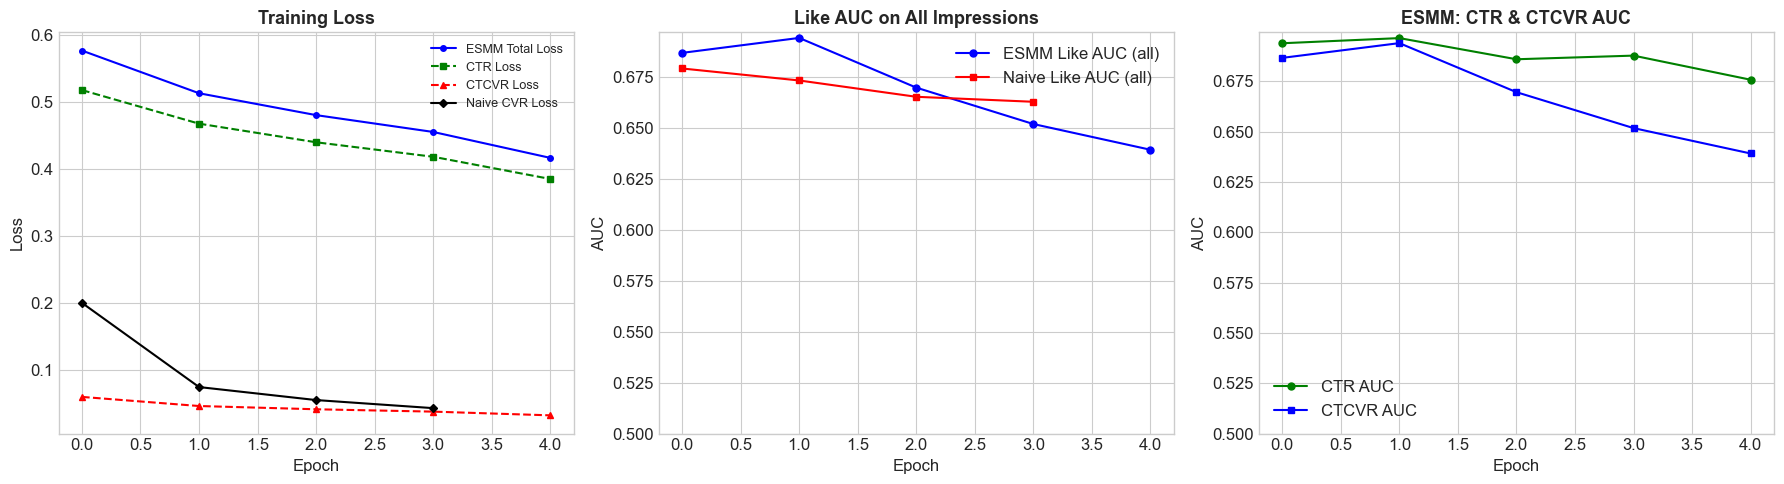

In [13]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
ax = axes[0]
ax.plot(esmm_history['train_loss'], 'b-o', label='ESMM Total Loss', markersize=4)
ax.plot(esmm_history['ctr_loss'], 'g--s', label='CTR Loss', markersize=4)
ax.plot(esmm_history['ctcvr_loss'], 'r--^', label='CTCVR Loss', markersize=4)
ax.plot(naive_history['train_loss'], 'k-D', label='Naive CVR Loss', markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Like AUC curves (all impressions)
ax = axes[1]
ax.plot(esmm_history['test_like_auc_all'], 'b-o', label='ESMM Like AUC (all)', markersize=5)
ax.plot(naive_history['test_like_auc_all'], 'r-s', label='Naive Like AUC (all)', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Like AUC on All Impressions', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, None)

# CTR & CTCVR AUC
ax = axes[2]
ax.plot(esmm_history['test_ctr_auc'], 'g-o', label='CTR AUC', markersize=5)
ax.plot(esmm_history['test_ctcvr_auc'], 'b-s', label='CTCVR AUC', markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('ESMM: CTR & CTCVR AUC', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0.5, None)

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'esmm_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

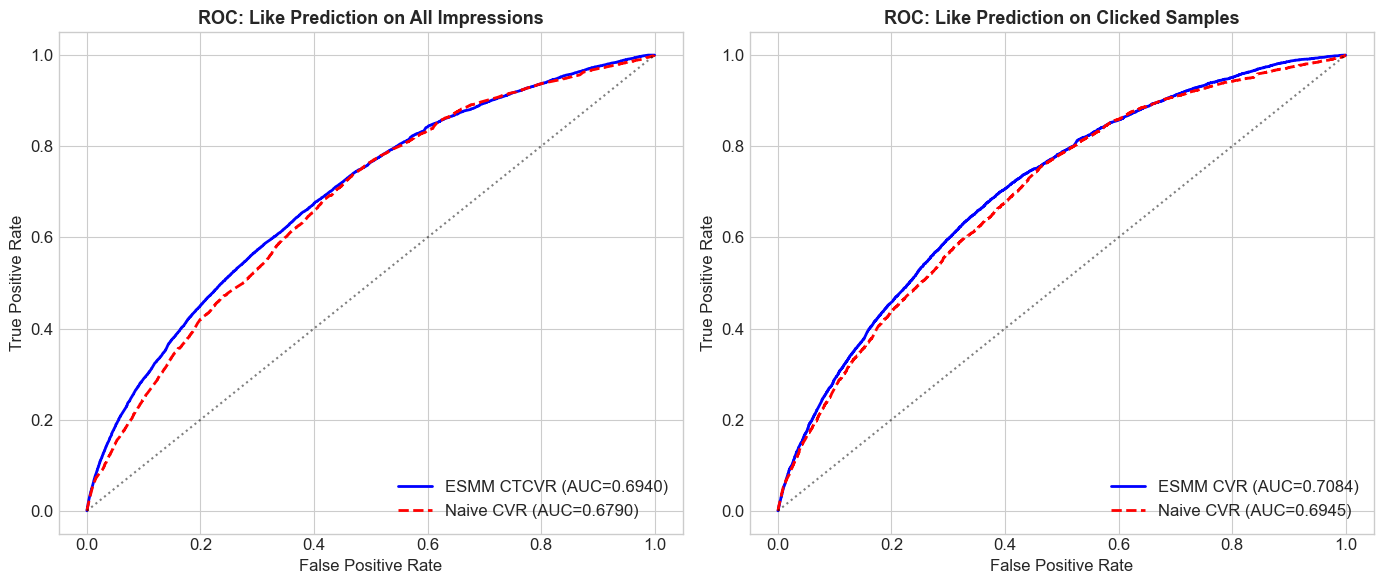

In [14]:
# ROC Curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Collect predictions
model_esmm.eval()
model_naive.eval()

all_esmm_ctcvr = []
all_esmm_cvr = []
all_naive_cvr = []
all_clicks = []
all_likes = []

with torch.no_grad():
    for features, clicks, likes in test_loader:
        features_gpu = features.to(device)
        
        ctr_p, cvr_p, ctcvr_p = model_esmm(features_gpu)
        naive_p = model_naive(features_gpu)
        
        all_esmm_ctcvr.append(ctcvr_p.cpu().numpy())
        all_esmm_cvr.append(cvr_p.cpu().numpy())
        all_naive_cvr.append(naive_p.cpu().numpy())
        all_clicks.append(clicks.numpy())
        all_likes.append(likes.numpy())

esmm_ctcvr_preds = np.concatenate(all_esmm_ctcvr)
esmm_cvr_preds = np.concatenate(all_esmm_cvr)
naive_cvr_preds = np.concatenate(all_naive_cvr)
test_clicks = np.concatenate(all_clicks)
test_likes = np.concatenate(all_likes)

# ROC on all impressions
ax = axes[0]
fpr, tpr, _ = roc_curve(test_likes, esmm_ctcvr_preds)
ax.plot(fpr, tpr, 'b-', linewidth=2,
        label=f'ESMM CTCVR (AUC={esmm_results["like_auc_all"]:.4f})')
fpr, tpr, _ = roc_curve(test_likes, naive_cvr_preds)
ax.plot(fpr, tpr, 'r--', linewidth=2,
        label=f'Naive CVR (AUC={naive_results["like_auc_all"]:.4f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: Like Prediction on All Impressions', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')

# ROC on clicked samples
ax = axes[1]
clicked_mask = test_clicks == 1
if clicked_mask.sum() > 0:
    fpr, tpr, _ = roc_curve(test_likes[clicked_mask], esmm_cvr_preds[clicked_mask])
    ax.plot(fpr, tpr, 'b-', linewidth=2,
            label=f'ESMM CVR (AUC={esmm_results["like_auc_clicked"]:.4f})')
    fpr, tpr, _ = roc_curve(test_likes[clicked_mask], naive_cvr_preds[clicked_mask])
    ax.plot(fpr, tpr, 'r--', linewidth=2,
            label=f'Naive CVR (AUC={naive_results["like_auc_clicked"]:.4f})')
ax.plot([0, 1], [0, 1], 'k:', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: Like Prediction on Clicked Samples', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(str(PROCESSED_DIR / 'esmm_roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Ablation Studies

In [15]:
# Ablation 1: Shared vs Separate Embeddings
print("=" * 70)
print("ABLATION 1: Shared vs Separate Embeddings")
print("=" * 70)

class ESMMSeparateEmbed(nn.Module):
    """ESMM with SEPARATE embeddings for CTR and CVR towers."""
    
    def __init__(self, feature_fields, embed_dim=16,
                 hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        self.ctr_embedding = SharedEmbedding(feature_fields, embed_dim)
        self.cvr_embedding = SharedEmbedding(feature_fields, embed_dim)
        self.ctr_tower = Tower(self.ctr_embedding.output_dim, hidden_dims, dropout)
        self.cvr_tower = Tower(self.cvr_embedding.output_dim, hidden_dims, dropout)
        self.ctcvr_loss_weight = 1.0
    
    def forward(self, x):
        ctr_embed = self.ctr_embedding(x)
        cvr_embed = self.cvr_embedding(x)
        ctr_pred = torch.sigmoid(self.ctr_tower(ctr_embed).squeeze(1))
        cvr_pred = torch.sigmoid(self.cvr_tower(cvr_embed).squeeze(1))
        ctcvr_pred = ctr_pred * cvr_pred
        return ctr_pred, cvr_pred, ctcvr_pred
    
    def compute_loss(self, ctr_pred, ctcvr_pred, click_label, like_label):
        ctr_loss = F.binary_cross_entropy(ctr_pred, click_label)
        ctcvr_pred_clipped = torch.clamp(ctcvr_pred, 1e-7, 1 - 1e-7)
        ctcvr_loss = F.binary_cross_entropy(ctcvr_pred_clipped, like_label)
        return ctr_loss + self.ctcvr_loss_weight * ctcvr_loss, ctr_loss, ctcvr_loss


torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

model_sep = ESMMSeparateEmbed(feature_fields, embed_dim=16,
                               hidden_dims=[256, 128, 64], dropout=0.3).to(device)
print(f"Separate embedding params: {sum(p.numel() for p in model_sep.parameters()):,}")
print(f"Shared embedding params:   {sum(p.numel() for p in model_esmm.parameters()):,}")

sep_history = train_esmm(model_sep, train_loader, test_loader,
                         n_epochs=10, lr=1e-3, patience=3)

sep_results = evaluate_model(model_sep, test_loader, model_type='esmm', device=device)

print(f"\nShared Embeddings CTCVR AUC: {esmm_results['ctcvr_auc']:.4f}")
print(f"Separate Embeddings CTCVR AUC: {sep_results['ctcvr_auc']:.4f}")

ABLATION 1: Shared vs Separate Embeddings
Separate embedding params: 21,535,266
Shared embedding params:   10,830,482


Epoch  1/10 (158.0s) | Loss: 0.5888 (CTR: 0.5224, CTCVR: 0.0664) | CTR AUC: 0.6872 | Like AUC (all): 0.6576 | CTCVR AUC: 0.6576 *


Epoch  2/10 (158.8s) | Loss: 0.5176 (CTR: 0.4705, CTCVR: 0.0471) | CTR AUC: 0.6946 | Like AUC (all): 0.6898 | CTCVR AUC: 0.6898 *


Epoch  3/10 (163.9s) | Loss: 0.4868 (CTR: 0.4452, CTCVR: 0.0416) | CTR AUC: 0.6918 | Like AUC (all): 0.6882 | CTCVR AUC: 0.6882


Epoch  4/10 (164.2s) | Loss: 0.4590 (CTR: 0.4211, CTCVR: 0.0379) | CTR AUC: 0.6851 | Like AUC (all): 0.6680 | CTCVR AUC: 0.6680


Epoch  5/10 (163.7s) | Loss: 0.4201 (CTR: 0.3876, CTCVR: 0.0325) | CTR AUC: 0.6796 | Like AUC (all): 0.6657 | CTCVR AUC: 0.6657

Early stopping at epoch 5 (no improvement for 3 epochs)

Best CTCVR AUC: 0.6898



Shared Embeddings CTCVR AUC: 0.6940
Separate Embeddings CTCVR AUC: 0.6898


In [16]:
# Ablation 2: CTCVR Loss Weight
print("=" * 70)
print("ABLATION 2: CTCVR Loss Weight")
print("=" * 70)

weight_results = {}

for weight in [0.5, 1.0, 2.0, 5.0]:
    print(f"\n--- CTCVR weight = {weight} ---")
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    
    model_w = ESMM(feature_fields, embed_dim=16, hidden_dims=[256, 128, 64],
                   dropout=0.3, ctcvr_loss_weight=weight).to(device)
    
    hist_w = train_esmm(model_w, train_loader, test_loader,
                        n_epochs=10, lr=1e-3, patience=3)
    
    res_w = evaluate_model(model_w, test_loader, model_type='esmm', device=device)
    weight_results[weight] = res_w

# Summary
print("\n" + "=" * 60)
print("CTCVR Loss Weight Ablation Summary")
print("=" * 60)
print(f"{'Weight':>8} {'CTR AUC':>10} {'Like AUC':>10} {'CTCVR AUC':>10}")
print("-" * 40)
for w, r in weight_results.items():
    print(f"{w:>8.1f} {r['ctr_auc']:>10.4f} {r['like_auc_all']:>10.4f} {r['ctcvr_auc']:>10.4f}")

ABLATION 2: CTCVR Loss Weight

--- CTCVR weight = 0.5 ---


Epoch  1/10 (178.7s) | Loss: 0.5579 (CTR: 0.5273, CTCVR: 0.0613) | CTR AUC: 0.6940 | Like AUC (all): 0.6892 | CTCVR AUC: 0.6892 *


Epoch  2/10 (187.5s) | Loss: 0.4911 (CTR: 0.4679, CTCVR: 0.0465) | CTR AUC: 0.6959 | Like AUC (all): 0.6809 | CTCVR AUC: 0.6809


Epoch  3/10 (189.4s) | Loss: 0.4609 (CTR: 0.4396, CTCVR: 0.0427) | CTR AUC: 0.6909 | Like AUC (all): 0.6523 | CTCVR AUC: 0.6523


Epoch  4/10 (164.2s) | Loss: 0.4225 (CTR: 0.4036, CTCVR: 0.0377) | CTR AUC: 0.6850 | Like AUC (all): 0.6432 | CTCVR AUC: 0.6432

Early stopping at epoch 4 (no improvement for 3 epochs)

Best CTCVR AUC: 0.6892


...

Epoch  1/10 (151.4s) | Loss: 0.8210 (CTR: 0.5335, CTCVR: 0.0575) | CTR AUC: 0.6926 | Like AUC (all): 0.6955 | CTCVR AUC: 0.6955 *


Epoch  2/10 (144.0s) | Loss: 0.6878 (CTR: 0.4728, CTCVR: 0.0430) | CTR AUC: 0.6920 | Like AUC (all): 0.6794 | CTCVR AUC: 0.6794


Epoch  3/10 (147.0s) | Loss: 0.6316 (CTR: 0.4501, CTCVR: 0.0363) | CTR AUC: 0.6857 | Like AUC (all): 0.6661 | CTCVR AUC: 0.6661


Epoch  4/10 (148.3s) | Loss: 0.5524 (CTR: 0.4116, CTCVR: 0.0282) | CTR AUC: 0.6764 | Like AUC (all): 0.6486 | CTCVR AUC: 0.6486

Early stopping at epoch 4 (no improvement for 3 epochs)

Best CTCVR AUC: 0.6955



CTCVR Loss Weight Ablation Summary
  Weight    CTR AUC   Like AUC  CTCVR AUC
----------------------------------------
     0.5     0.6940     0.6892     0.6892
     1.0     0.6939     0.6942     0.6942
     2.0     0.6941     0.6939     0.6939
     5.0     0.6926     0.6955     0.6955


In [17]:
# Save model and results
torch.save(model_esmm.state_dict(), str(PROCESSED_DIR / 'esmm_model.pt'))
torch.save(model_naive.state_dict(), str(PROCESSED_DIR / 'naive_cvr_model.pt'))

def convert_for_json(obj):
    if isinstance(obj, np.floating): return float(obj)
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, dict): return {k: convert_for_json(v) for k, v in obj.items()}
    if isinstance(obj, list): return [convert_for_json(v) for v in obj]
    return obj

results_to_save = {
    'esmm': convert_for_json(esmm_results),
    'naive_cvr': convert_for_json(naive_results),
    'esmm_history': convert_for_json(esmm_history),
    'naive_history': convert_for_json(naive_history),
}

with open(PROCESSED_DIR / 'esmm_results.json', 'w') as f:
    json.dump(results_to_save, f, indent=2)

print("Models and results saved.")

Models and results saved.


---

## Exercises

### Exercise 1: Add Focal Loss for CTCVR
The like label is extremely imbalanced (~0.6% positive overall). Implement focal loss for the CTCVR component and test whether it improves Like AUC.

In [18]:
# TODO: Exercise 1
# Implement focal loss: FL(p) = -alpha * (1-p)^gamma * log(p)
# Replace the CTCVR BCE loss with focal loss (gamma=2, alpha=0.25)
# Compare AUC with standard BCE

# def focal_loss(pred, target, gamma=2.0, alpha=0.25):
#     ...

pass

### Exercise 2: Embedding Dimension Study
Try different embedding dimensions (4, 8, 16, 32) and compare:
1. Model size (parameter count)
2. Training speed (seconds per epoch)
3. Final AUC

In [19]:
# TODO: Exercise 2
# Loop over embed_dims = [4, 8, 16, 32]
# For each, create ESMM model, train for 5 epochs, record metrics

pass

### Exercise 3: What Happens with Direct CVR Loss?
Modify ESMM to add a direct CVR loss (BCE between CVR tower output and like label on clicked samples). Does this help or hurt?

In [20]:
# TODO: Exercise 3
# Modify compute_loss to add:
# L_CVR_direct = BCE(cvr_pred[clicked], like[clicked])
# L_total = L_CTR + L_CTCVR + alpha * L_CVR_direct
# Test with alpha = 0.1, 0.5, 1.0

pass

### Exercise 4: Calibration Analysis
Plot calibration curves for ESMM predictions (predicted vs actual like rate in deciles). Is the ESMM model well-calibrated?

In [21]:
# TODO: Exercise 4
# Hint: Bin CTCVR predictions into 10 buckets
# For each bucket, compute mean predicted and actual like rate
# Plot predicted vs actual; a perfect model lies on the diagonal

pass

---

## Summary & Key Takeaways

### What We Learned

1. **ESMM eliminates Sample Selection Bias**: By using the multiplication trick (CTCVR = CTR x CVR) and training on all impressions, ESMM avoids the distribution mismatch of naive like models.

2. **Shared embeddings matter**: Sharing feature embeddings between CTR and CVR towers provides implicit regularization and better feature learning. The CTR task (with ~27% positive rate) helps the CVR task learn better representations.

3. **Loss design is critical**: The ESMM loss only contains $\mathcal{L}_{CTR}$ and $\mathcal{L}_{CTCVR}$. Adding a direct CVR loss re-introduces the bias.

4. **Practical results**: ESMM consistently outperforms naive CVR on the full impression space, which is the real-world evaluation scenario. Target: Like AUC >= 0.70.

### Next Steps

- **Notebook 03**: Replace the tower architecture with expert-based routing (MMoE, PLE) for better multi-task learning
- **Notebook 04**: Comprehensive comparison of all models

> **Pro Tip:** In production, ESMM's CTR and CVR predictions can be used independently. The CTR score drives click-based ranking, while CTCVR drives like-optimized ranking. You can also use the CVR score for post-click optimization.